In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def load_data():
    data_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
    try:
        df = pd.read_csv(data_url)
        print("Dataset loaded successfully.")
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return None, None

    df.columns = [c.upper() for c in df.columns]

    X = df[['RM', 'CRIM']].values
    y = df['MEDV'].values.reshape(-1, 1)

    return X, y

In [4]:
def normalize_data(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)

    # Avoid division by zero
    std[std == 0] = 1
    X_scaled = (X - mean) / std
    return X_scaled, mean, std

In [5]:
def train_test_split(X, y, split_ratio=0.8):
    # Shuffle indices
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    split_index = int(X.shape[0] * split_ratio)

    train_indices = indices[:split_index]
    test_indices = indices[split_index:]

    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    return X_train, X_test, y_train, y_test

In [6]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_layers, output_size, optimizer='sgd', learning_rate=0.01, l2_lambda=0.0):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_layers = hidden_layers
        self.optimizer = optimizer
        self.lr = learning_rate
        self.l2_lambda = l2_lambda

        self.params = {}
        self.layer_dims = [input_size] + hidden_layers + [output_size]

        for i in range(1, len(self.layer_dims)):
            self.params['W' + str(i)] = np.random.randn(self.layer_dims[i-1], self.layer_dims[i]) * np.sqrt(2. / self.layer_dims[i-1])
            self.params['b' + str(i)] = np.zeros((1, self.layer_dims[i]))

        self.grads = {}
        self.v = {}
        self.s = {}

        for i in range(1, len(self.layer_dims)):
            self.v['dW' + str(i)] = np.zeros_like(self.params['W' + str(i)])
            self.v['db' + str(i)] = np.zeros_like(self.params['b' + str(i)])
            self.s['dW' + str(i)] = np.zeros_like(self.params['W' + str(i)])
            self.s['db' + str(i)] = np.zeros_like(self.params['b' + str(i)])

        self.t = 0


    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def linear(self, Z):
        return Z

    # Forward Propagation
    def forward(self, X):
        self.cache = {}
        A = X
        L = len(self.layer_dims) - 1

        for i in range(1, L):
            Z = np.dot(A, self.params['W' + str(i)]) + self.params['b' + str(i)]
            A = self.relu(Z)
            self.cache['Z' + str(i)] = Z
            self.cache['A' + str(i)] = A

        Z = np.dot(A, self.params['W' + str(L)]) + self.params['b' + str(L)]
        A = self.linear(Z)
        self.cache['Z' + str(L)] = Z
        self.cache['A' + str(L)] = A
        self.cache['A0'] = X

        return A

    # Loss Function (MSE)
    def compute_loss(self, y_pred, y_true):
        m = y_true.shape[0]
        mse = (1 / (2 * m)) * np.sum((y_pred - y_true) ** 2)

        l2_cost = 0
        if self.l2_lambda > 0:
            L = len(self.layer_dims) - 1
            for i in range(1, L + 1):
                l2_cost += np.sum(np.square(self.params['W' + str(i)]))
            l2_cost *= (self.l2_lambda / (2 * m))

        return mse + l2_cost


    # Backward Propagation
    def backward(self, y_pred, y_true):
        m = y_true.shape[0]
        L = len(self.layer_dims) - 1
        self.grads = {}

        dZ = (y_pred - y_true)

        self.grads['dW' + str(L)] = (1 / m) * np.dot(self.cache['A' + str(L-1)].T, dZ)
        self.grads['db' + str(L)] = (1 / m) * np.sum(dZ, axis=0, keepdims=True)

        if self.l2_lambda > 0:
            self.grads['dW' + str(L)] += (self.l2_lambda / m) * self.params['W' + str(L)]

        for i in range(L-1, 0, -1):
            dA = np.dot(dZ, self.params['W' + str(i+1)].T)
            dZ = dA * self.relu_derivative(self.cache['Z' + str(i)])

            self.grads['dW' + str(i)] = (1 / m) * np.dot(self.cache['A' + str(i-1)].T, dZ)
            self.grads['db' + str(i)] = (1 / m) * np.sum(dZ, axis=0, keepdims=True)

            if self.l2_lambda > 0:
                self.grads['dW' + str(i)] += (self.l2_lambda / m) * self.params['W' + str(i)]

    # Update Parameters
    def update_parameters(self):
        L = len(self.layer_dims) - 1

        if self.optimizer == 'sgd':
            for i in range(1, L + 1):
                self.params['W' + str(i)] -= self.lr * self.grads['dW' + str(i)]
                self.params['b' + str(i)] -= self.lr * self.grads['db' + str(i)]

        elif self.optimizer == 'momentum':
            beta = 0.9
            for i in range(1, L + 1):
                self.v['dW' + str(i)] = beta * self.v['dW' + str(i)] + self.lr * self.grads['dW' + str(i)]
                self.v['db' + str(i)] = beta * self.v['db' + str(i)] + self.lr * self.grads['db' + str(i)]

                self.params['W' + str(i)] -= self.v['dW' + str(i)]
                self.params['b' + str(i)] -= self.v['db' + str(i)]

        elif self.optimizer == 'adam':
            beta1 = 0.9
            beta2 = 0.999
            epsilon = 1e-8
            self.t += 1

            for i in range(1, L + 1):
                # Momentum (1st moment)
                self.v['dW' + str(i)] = beta1 * self.v['dW' + str(i)] + (1 - beta1) * self.grads['dW' + str(i)]
                self.v['db' + str(i)] = beta1 * self.v['db' + str(i)] + (1 - beta1) * self.grads['db' + str(i)]

                # RMSProp (2nd moment)
                self.s['dW' + str(i)] = beta2 * self.s['dW' + str(i)] + (1 - beta2) * (self.grads['dW' + str(i)]**2)
                self.s['db' + str(i)] = beta2 * self.s['db' + str(i)] + (1 - beta2) * (self.grads['db' + str(i)]**2)

                # Bias correction
                v_corrected_dw = self.v['dW' + str(i)] / (1 - beta1**self.t)
                v_corrected_db = self.v['db' + str(i)] / (1 - beta1**self.t)
                s_corrected_dw = self.s['dW' + str(i)] / (1 - beta2**self.t)
                s_corrected_db = self.s['db' + str(i)] / (1 - beta2**self.t)

                # Update
                self.params['W' + str(i)] -= self.lr * (v_corrected_dw / (np.sqrt(s_corrected_dw) + epsilon))
                self.params['b' + str(i)] -= self.lr * (v_corrected_db / (np.sqrt(s_corrected_db) + epsilon))

    def fit(self, X_train, y_train, epochs=1000, verbose=False):
        loss_history = []
        for epoch in range(epochs):
            y_pred = self.forward(X_train)

            loss = self.compute_loss(y_pred, y_train)
            loss_history.append(loss)

            self.backward(y_pred, y_train)

            self.update_parameters()

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}: Loss {loss:.4f}")

        return loss_history

    def predict(self, X):
        return self.forward(X)

In [7]:
def prepare_data():
    X, y = load_data()
    if X is None:
        return None, None, None, None

    X_scaled, mean_X, std_X = normalize_data(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, split_ratio=0.8)

    print(f"Training Data Shape: {X_train.shape}")
    print(f"Test Data Shape: {X_test.shape}")

    return X_train, X_test, y_train, y_test

In [8]:
def run_optimizer_experiments(X_train, y_train, X_test, y_test):
    input_size = 2
    hidden_structure = [5, 3]
    output_size = 1
    epochs = 1000
    learning_rates = [0.01, 0.001]
    optimizers = ['sgd', 'momentum', 'adam']

    results = {}

    print("\n--- Starting Optimizer Experiments ---")
    for opt in optimizers:
        for lr in learning_rates:
            print(f"Training with Optimizer: {opt}, LR: {lr}")

            model = NeuralNetwork(input_size, hidden_structure, output_size,
                                  optimizer=opt, learning_rate=lr)

            losses = model.fit(X_train, y_train, epochs=epochs, verbose=False)

            y_pred_test = model.predict(X_test)
            test_mse = np.mean((y_pred_test - y_test) ** 2)
            print(f"  Final Test MSE: {test_mse:.4f}")

            results[(opt, lr)] = {'losses': losses, 'mse': test_mse, 'model': model}

    return results

In [9]:
def plot_loss_curves(results):
    plt.figure(figsize=(15, 10))
    plot_idx = 1

    sorted_keys = sorted(results.keys())

    for key in sorted_keys:
        opt, lr = key
        data = results[key]

        plt.subplot(2, 3, plot_idx)
        plt.plot(data['losses'])
        plt.title(f"{opt.upper()} (LR={lr})\nTest MSE: {data['mse']:.2f}")
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.grid(True)
        plot_idx += 1

    plt.tight_layout()
    plt.show()

In [10]:
def additional(X_train, y_train, X_test, y_test):
    input_size = 2
    output_size = 1

    print("\n---1: 3 Hidden Layers [5, 3, 2] ---")
    bonus_hidden = [5, 3, 2]
    model_b1 = NeuralNetwork(input_size, bonus_hidden, output_size, optimizer='adam', learning_rate=0.01)
    model_b1.fit(X_train, y_train, epochs=1000)

    y_pred_b1 = model_b1.predict(X_test)
    mse_b1 = np.mean((y_pred_b1 - y_test) ** 2)
    print(f"3 Hidden Layers Test MSE: {mse_b1:.4f}")


    print("\n---2: L2 Regularization (Lambda=0.1) ---")
    hidden_structure = [5, 3]
    model_l2 = NeuralNetwork(input_size, hidden_structure, output_size,
                             optimizer='adam', learning_rate=0.01, l2_lambda=0.1)
    model_l2.fit(X_train, y_train, epochs=1000)

    y_pred_l2 = model_l2.predict(X_test)
    mse_l2 = np.mean((y_pred_l2 - y_test) ** 2)
    print(f"L2 Regularized Test MSE: {mse_l2:.4f}")

In [11]:
def plot_final_predictions(best_model, X_test, y_test, title_info):
    y_pred = best_model.predict(X_test)

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.7, color='blue')


    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    plt.xlabel('Actual MEDV')
    plt.ylabel('Predicted MEDV')
    plt.title(f'Actual vs Predicted ({title_info})')
    plt.grid(True)
    plt.show()

In [12]:
def main_task2():
    X_train, X_test, y_train, y_test = prepare_data()
    if X_train is None: return

    results = run_optimizer_experiments(X_train, y_train, X_test, y_test)

    plot_loss_curves(results)

    additional(X_train, y_train, X_test, y_test)

    best_key = min(results, key=lambda k: results[k]['mse'])
    best_model = results[best_key]['model']

    print(f"\nBest Model Found: {best_key[0]} (LR={best_key[1]}) with MSE: {results[best_key]['mse']:.4f}")

    plot_final_predictions(best_model, X_test, y_test,
                           title_info=f"Best Model: {best_key[0]}, LR={best_key[1]}")

Dataset loaded successfully.
Training Data Shape: (404, 2)
Test Data Shape: (102, 2)

--- Starting Optimizer Experiments ---
Training with Optimizer: sgd, LR: 0.01
  Final Test MSE: 23.8203
Training with Optimizer: sgd, LR: 0.001
  Final Test MSE: 22.0116
Training with Optimizer: momentum, LR: 0.01
  Final Test MSE: 25.2581
Training with Optimizer: momentum, LR: 0.001
  Final Test MSE: 21.7115
Training with Optimizer: adam, LR: 0.01
  Final Test MSE: 21.9124
Training with Optimizer: adam, LR: 0.001
  Final Test MSE: 42.2614


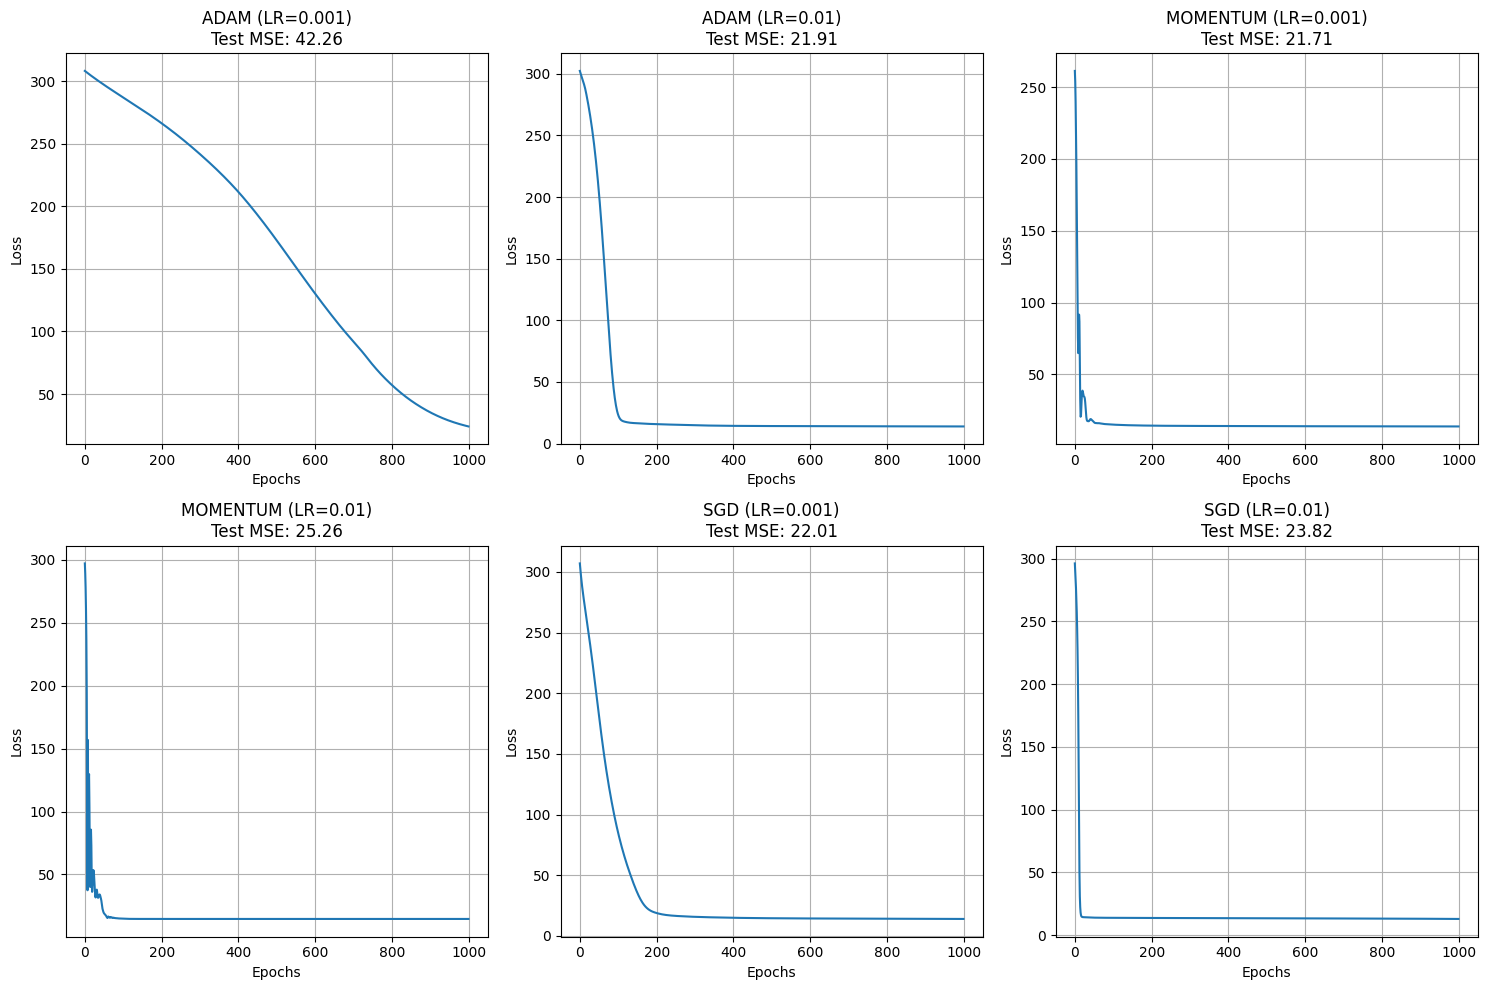


---1: 3 Hidden Layers [5, 3, 2] ---
3 Hidden Layers Test MSE: 278.1228

---2: L2 Regularization (Lambda=0.1) ---
L2 Regularized Test MSE: 22.5813

Best Model Found: momentum (LR=0.001) with MSE: 21.7115


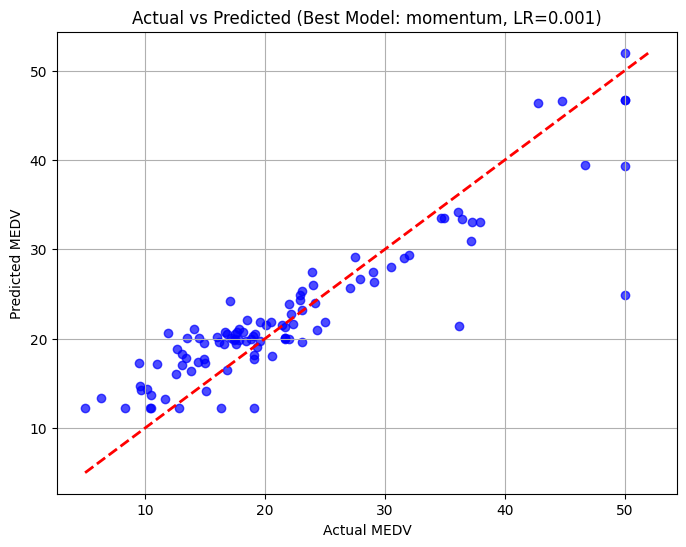

In [13]:
if __name__ == "__main__":
    main_task2()